In [1]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
!pip install torchinfo
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt
import time

## **ResNet-34, ResNet-50 구현하기**  
- 블록함수 구현 + summary 출력
- loss 가 감소하는 거 확인하기
- plain 모델과 residubal 모델을 동일한 epoch 만큼 학습 시켰을 때 valdation accuracy 표 작성

![nn](./resnet_image.png)

In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

In [3]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 224, 224])
Label: 6
Number of classes: 10


In [4]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [5]:

class PlainBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = F.relu(out)

        return out

In [6]:

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            inplanes, planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or inplanes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes, self.expansion*planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [7]:
class BottleneckBlock(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            inplanes, planes,
            kernel_size=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes, planes,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(
            planes, self.expansion*planes,
            kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(self.expansion*planes)
        self.relu = nn.ReLU(inplace=True)

        self.shortcut = nn.Sequential()
        if stride != 1 or inplanes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    inplanes, self.expansion*planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv3(out)
        out = self.bn3(out)
        out += self.shortcut(x)
        out = self.relu(out)
        return out

In [8]:
import torch


class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super().__init__()

        self.inplanes = 64
        self.stem = nn.Sequential(
            nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(self.inplanes),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        ) 
        self.stage1 = self._make_layer(block, 64, layers[0], stride=1)
        self.stage2 = self._make_layer(block, 128, layers[1], stride=2)
        self.stage3 = self._make_layer(block, 256, layers[2], stride=2)
        self.stage4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        layers = []
        layers.append(block(self.inplanes, planes, stride))
        self.inplanes = planes * block.expansion
        for _ in range(num_blocks - 1):
            layers.append(block(self.inplanes, planes, 1))
        
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.stem(x)
        out = self.stage1(out)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [9]:
from torchvision import models
from torchinfo import summary


resnet_plain = ResNet(PlainBlock, [3, 4, 6, 3], 1000)
resnet34 = ResNet(BasicBlock, [3, 4, 6, 3], 1000)
resnet50 = ResNet(BottleneckBlock, [3, 4, 6, 3], 1000)

### **ResNet-34 Summary**

In [10]:
summary(resnet34)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       9,408
│    └─BatchNorm2d: 2-2                  128
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
├─Sequential: 1-2                        --
│    └─BasicBlock: 2-5                   --
│    │    └─Conv2d: 3-1                  36,864
│    │    └─BatchNorm2d: 3-2             128
│    │    └─ReLU: 3-3                    --
│    │    └─Conv2d: 3-4                  36,864
│    │    └─BatchNorm2d: 3-5             128
│    │    └─Sequential: 3-6              --
│    └─BasicBlock: 2-6                   --
│    │    └─Conv2d: 3-7                  36,864
│    │    └─BatchNorm2d: 3-8             128
│    │    └─ReLU: 3-9                    --
│    │    └─Conv2d: 3-10                 36,864
│    │    └─BatchNorm2d: 3-11            128
│    │    └─Sequential: 3-12             --
│  

### **ResNet-50 Summary**

In [11]:
summary(resnet50)

Layer (type:depth-idx)                   Param #
ResNet                                   --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       9,408
│    └─BatchNorm2d: 2-2                  128
│    └─ReLU: 2-3                         --
│    └─MaxPool2d: 2-4                    --
├─Sequential: 1-2                        --
│    └─BottleneckBlock: 2-5              --
│    │    └─Conv2d: 3-1                  4,096
│    │    └─BatchNorm2d: 3-2             128
│    │    └─Conv2d: 3-3                  36,864
│    │    └─BatchNorm2d: 3-4             128
│    │    └─Conv2d: 3-5                  16,384
│    │    └─BatchNorm2d: 3-6             512
│    │    └─ReLU: 3-7                    --
│    │    └─Sequential: 3-8              16,896
│    └─BottleneckBlock: 2-6              --
│    │    └─Conv2d: 3-9                  16,384
│    │    └─BatchNorm2d: 3-10            128
│    │    └─Conv2d: 3-11                 36,864
│    │    └─BatchNorm2d: 3-12           

In [12]:
def train_model(model, model_name, trainloader, testloader, loss_fn, device, EPOCH):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(EPOCH):
        # 🔥 train
        model.train()
        running_loss, correct, total = 0, 0, 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct / total

        # 🔥 test
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f"{model_name} | Epoch {epoch+1}: Train Acc {train_acc:.2f}%, Test Acc {test_acc:.2f}%")

    return train_losses, train_accs, test_accs

In [13]:
EPOCH=9

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loss_fn = nn.CrossEntropyLoss()

In [17]:
plain_loss, plain_train_acc, plain_test_acc = train_model(
    resnet_plain, "ResNet_Plain", trainloader, testloader, loss_fn, device, EPOCH
)

ResNet_Plain | Epoch 1: Train Acc 52.54%, Test Acc 52.24%
ResNet_Plain | Epoch 2: Train Acc 60.86%, Test Acc 56.84%
ResNet_Plain | Epoch 3: Train Acc 66.53%, Test Acc 62.85%
ResNet_Plain | Epoch 4: Train Acc 71.17%, Test Acc 71.27%
ResNet_Plain | Epoch 5: Train Acc 74.73%, Test Acc 71.25%
ResNet_Plain | Epoch 6: Train Acc 77.09%, Test Acc 73.16%
ResNet_Plain | Epoch 7: Train Acc 79.88%, Test Acc 74.60%
ResNet_Plain | Epoch 8: Train Acc 82.07%, Test Acc 74.61%
ResNet_Plain | Epoch 9: Train Acc 83.92%, Test Acc 76.66%


In [16]:
r34_loss, r34_train_acc, r34_test_acc = train_model(
    resnet34, "ResNet34", trainloader, testloader, loss_fn, device, EPOCH
)

ResNet34 | Epoch 1: Train Acc 41.54%, Test Acc 48.86%
ResNet34 | Epoch 2: Train Acc 63.92%, Test Acc 65.23%
ResNet34 | Epoch 3: Train Acc 74.04%, Test Acc 72.39%
ResNet34 | Epoch 4: Train Acc 79.41%, Test Acc 77.17%
ResNet34 | Epoch 5: Train Acc 83.08%, Test Acc 79.80%
ResNet34 | Epoch 6: Train Acc 86.07%, Test Acc 80.62%
ResNet34 | Epoch 7: Train Acc 88.35%, Test Acc 83.49%
ResNet34 | Epoch 8: Train Acc 90.71%, Test Acc 81.78%
ResNet34 | Epoch 9: Train Acc 92.38%, Test Acc 81.42%


In [15]:
r50_loss, r50_train_acc, r50_test_acc = train_model(
    resnet50, "ResNet50", trainloader, testloader, loss_fn, device, EPOCH
)

ResNet50 | Epoch 1: Train Acc 44.34%, Test Acc 47.44%
ResNet50 | Epoch 2: Train Acc 61.54%, Test Acc 61.97%
ResNet50 | Epoch 3: Train Acc 69.77%, Test Acc 66.14%
ResNet50 | Epoch 4: Train Acc 75.08%, Test Acc 70.05%
ResNet50 | Epoch 5: Train Acc 79.64%, Test Acc 74.20%
ResNet50 | Epoch 6: Train Acc 82.34%, Test Acc 78.52%
ResNet50 | Epoch 7: Train Acc 84.90%, Test Acc 76.78%
ResNet50 | Epoch 8: Train Acc 86.78%, Test Acc 78.12%
ResNet50 | Epoch 9: Train Acc 88.62%, Test Acc 81.72%


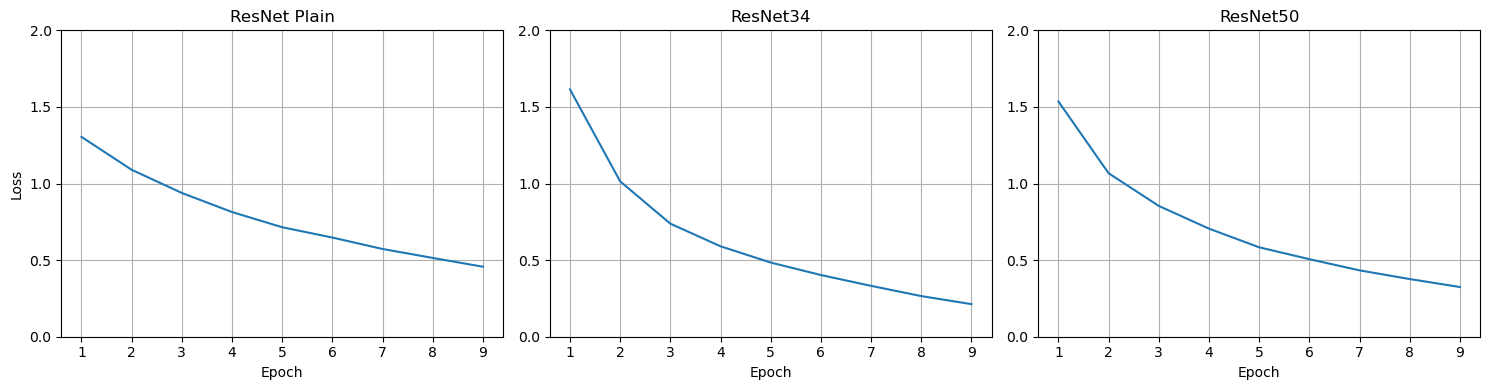

In [33]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCH + 1)

plt.figure(figsize=(15, 4))

# 🔹 Plain
plt.subplot(1, 3, 1)
plt.plot(epochs, plain_loss)
plt.title("ResNet Plain")
plt.xlabel("Epoch")
plt.ylim(0,2)
plt.grid()
plt.yticks(np.arange(0, 2.5, 0.5)) 
plt.ylabel("Loss")

# 🔹 ResNet34
plt.subplot(1, 3, 2)
plt.plot(epochs, r34_loss)
plt.title("ResNet34")
plt.ylim(0,2)
plt.grid()
plt.yticks(np.arange(0, 2.5, 0.5)) 
plt.xlabel("Epoch")

# 🔹 ResNet50
plt.subplot(1, 3, 3)
plt.plot(epochs, r50_loss)
plt.title("ResNet50")
plt.xlabel("Epoch")
plt.ylim(0,2)
plt.grid()
plt.yticks(np.arange(0, 2.5, 0.5)) 
plt.tight_layout()
plt.show()

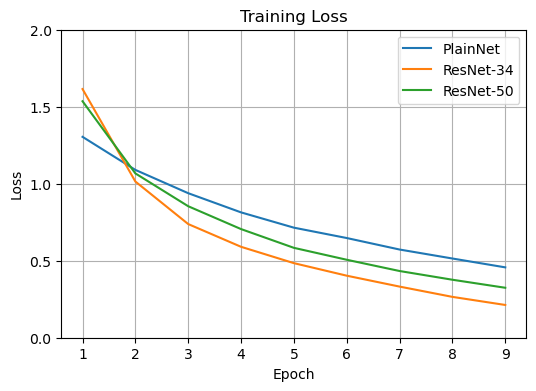

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCH + 1)

plt.figure(figsize=(6, 4))

plt.plot(epochs, plain_loss, label="PlainNet")
plt.plot(epochs, r34_loss, label="ResNet-34")
plt.plot(epochs, r50_loss, label="ResNet-50")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid()
plt.yticks(np.arange(0, 2.5, 0.5)) 
plt.ylim(0,2)
plt.show()

In [24]:
def summarize_results(acc_list):
    best_acc = max(acc_list)
    final_acc = acc_list[-1]
    best_epoch = acc_list.index(best_acc) + 1

    return best_acc, final_acc, best_epoch

In [25]:
plain_best, plain_final, plain_epoch = summarize_results(plain_test_acc)
r34_best, r34_final, r34_epoch = summarize_results(r34_test_acc)
r50_best, r50_final, r50_epoch = summarize_results(r50_test_acc)

In [26]:
print("Plain:", plain_best, plain_final, plain_epoch)
print("ResNet34:", r34_best, r34_final, r34_epoch)
print("ResNet50:", r50_best, r50_final, r50_epoch)

Plain: 76.66 76.66 9
ResNet34: 83.49 81.42 7
ResNet50: 81.72 81.72 9


### **Ablation Table**

|        | PlainNet | ResNet-34 | ResNet-50 |
|--------|----------|-----------|-----------|
| Accuracy | 76.66   | 83.49     | 81.72     |

회고  
- PlainNet 에 Residual Learning/ BottleNeck Block 을 추가하여 ResNet을 구현해보는 프로젝트였다
- Skip connection은 다음 단계에서도 계속 사용하니까 중요한데, 혼자서 하라고 하면 못하겠다
- identity 를 기본으로 t+n을 예측하는 기후데이터에서 유용하게 사용할 수 있겠다
- 폭염같이 하루만에 급격히 온도가 높아지는 event는 어려울지도